# Tutorial: propagate an astrometric catalog

This notebook demonstrates how proper motion, annual parallax, and aberration are applied in the current warpfield design. These effects are no longer handled by telescope optics. Instead, `AstrometricCatalog` stores astrometric parameters at a reference epoch and its `propagate()` method generates apparent source positions for a specified `Observer`.

## 1. Imports and plotting configuration

`AstrometricCatalog` and the Astropy-based observer frames are preprocessing components rather than differentiable Zodiax models. `propagate()` returns a `SourceCatalog`, which is the compact `(N_source,)` PyTree consumed by the astrometric model.

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

matplotlib.rcParams['legend.frameon'] = False
matplotlib.rcParams['figure.dpi'] = 72

In [2]:
from astropy.coordinates import Angle, SkyCoord
from astropy.time import Time
import astropy.units as u

from warpfield import AstrometricCatalog, SourceCatalog
from warpfield.observer import GeoCentric

## 2. Define astrometric parameters at a reference epoch

Two artificial sources are placed at the same ICRS coordinate near M2. They have identical proper motions but different parallaxes: 1000 mas and 0.1 mas. The second source therefore acts as a nearly distant reference when we subtract the two apparent positions.

The reference epoch is J2016.0 in the TCB scale. Radial velocity is not part of `AstrometricCatalog`; this example consequently propagates the five standard astrometric parameters stored by the class.

In [3]:
center = SkyCoord(
  ra=323.36258 * u.deg,
  dec=-0.82325 * u.deg,
  frame='icrs',
)
reference_epoch = Time(2016.0, format='decimalyear', scale='tcb')

catalog = AstrometricCatalog(
  ra=np.full(2, center.ra.degree) * u.deg,
  dec=np.full(2, center.dec.degree) * u.deg,
  pm_ra_cosdec=np.full(2, 50.0) * u.mas / u.yr,
  pm_dec=np.zeros(2) * u.mas / u.yr,
  parallax=np.array([1000.0, 0.0001]) * u.mas,
  epoch=reference_epoch,
)

catalog.to_qtable()

source_id,ra,dec,pm_ra_cosdec,pm_dec,parallax,epoch
,deg,deg,mas / yr,mas / yr,mas,
int64,float64,float64,float64,float64,float64,Time
0,323.36258,-0.82325,50.0,0.0,1000.0,2016.0
1,323.36258,-0.82325,50.0,0.0,0.0001,2016.0


## 3. Propagate to one observer epoch

`GeoCentric(obstime)` represents an observer at the geocenter. Its frame is aligned with the ICRS axes, while Astropy supplies the Earth's barycentric position and velocity. Transforming into this frame therefore applies annual parallax and aberration in addition to the catalog's space motion.

`propagate()` first advances the catalog coordinates from the reference epoch to `observer.obstime`, then transforms them into the observer frame. Observer-dependent options are encoded by the observer object rather than by flags on `propagate()`.

In [4]:
observer = GeoCentric(Time(2017.0, format='decimalyear', scale='tcb'))
apparent_source = catalog.propagate(observer)

assert isinstance(apparent_source, SourceCatalog)
apparent_source.to_qtable()

/home/rohsawa/.pyenv/versions/jasmine/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "pmsafe" yielded 1 of "distance overridden (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


source_id,ra,dec
,deg,deg
int64,float64,float64
0,323.35824840865575,-0.8238319025366728
1,323.35841774798024,-0.8237273902520914


## 4. Generate a three-year apparent-position sequence

Warpfield treats a group of exposures with negligible time separation as one astrometric epoch. For this tutorial we deliberately evaluate many independent epochs to visualize the time dependence. Each call still returns a one-dimensional `SourceCatalog` containing both sources.

In [5]:
obstime = reference_epoch + np.linspace(0.0, 3.0, 101) * u.yr
elapsed_year = (obstime - reference_epoch).to_value(u.yr)

apparent = np.empty((len(obstime), len(catalog), 2))
for epoch_id, epoch in enumerate(obstime):
  source_at_epoch = catalog.propagate(GeoCentric(epoch))
  apparent[epoch_id, :, 0] = np.asarray(source_at_epoch.ra)
  apparent[epoch_id, :, 1] = np.asarray(source_at_epoch.dec)

apparent.shape

(101, 2, 2)

The helper below converts longitude and latitude differences into local tangent-plane offsets. Right-ascension differences include the cosine-declination factor and are wrapped across the 0°/360° boundary.

In [6]:
def tangent_offsets(ra, dec, reference):
  delta_ra = Angle(
    (ra - reference.ra.degree) * u.deg,
  ).wrap_at(180 * u.deg)
  x = delta_ra.to_value(u.mas) * np.cos(reference.dec.to_value(u.rad))
  y = (dec - reference.dec.degree) * u.deg.to(u.mas)
  return x, y


offset_x, offset_y = tangent_offsets(
  apparent[:, :, 0],
  apparent[:, :, 1],
  center,
)

## 5. Apparent motion relative to the reference coordinate

Both tracks contain the common 50 mas/yr proper motion and the much larger annual aberration caused by the Earth's velocity. Their small separation is produced primarily by the difference in annual parallax.

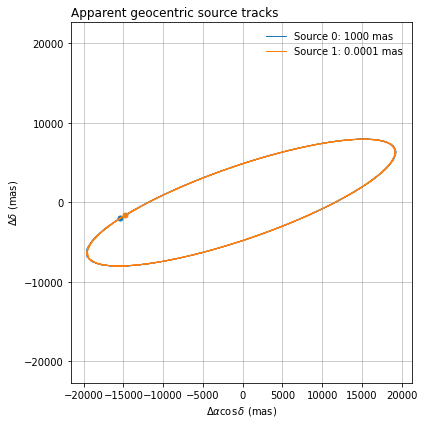

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
for source_id, parallax in enumerate(catalog.parallax):
  ax.plot(
    offset_x[:, source_id],
    offset_y[:, source_id],
    lw=1,
    label=f'Source {source_id}: {parallax.to_value(u.mas):g} mas',
  )
  ax.scatter(
    offset_x[0, source_id],
    offset_y[0, source_id],
    s=25,
  )

ax.grid(True, color='gray', alpha=0.5)
ax.set_aspect(1.0, adjustable='datalim')
ax.set_title('Apparent geocentric source tracks', loc='left')
ax.set_xlabel(r'$\Delta\alpha\cos\delta$ (mas)')
ax.set_ylabel(r'$\Delta\delta$ (mas)')
ax.legend(loc='best')
fig.tight_layout()
plt.show()

A time-series view separates the secular proper-motion trend from the periodic observer-dependent terms. The values shown here are apparent geocentric coordinates, not focal-plane positions.

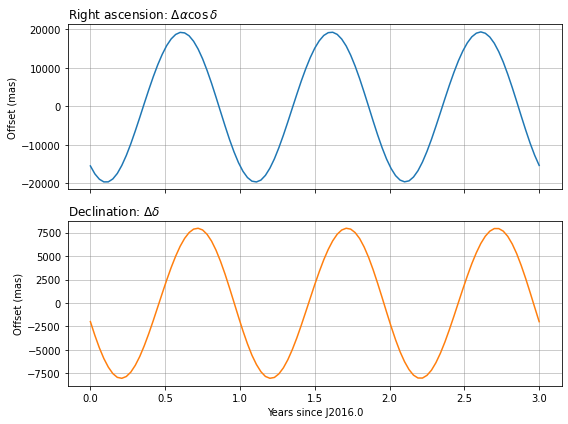

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axes[0].plot(elapsed_year, offset_x[:, 0], color='C0')
axes[1].plot(elapsed_year, offset_y[:, 0], color='C1')

axes[0].set_title(r'Right ascension: $\Delta\alpha\cos\delta$', loc='left')
axes[1].set_title(r'Declination: $\Delta\delta$', loc='left')
axes[0].set_ylabel('Offset (mas)')
axes[1].set_ylabel('Offset (mas)')
axes[1].set_xlabel('Years since J2016.0')
for ax in axes:
  ax.grid(True, color='gray', alpha=0.5)

fig.tight_layout()
plt.show()

## 6. Isolate annual parallax with differential astrometry

Subtracting the nearly distant source removes the common proper motion and most of the common aberration. The remaining ellipse is dominated by the approximately 1 arcsec parallax difference. This differential construction mirrors the way common observer-dependent motion can be separated from source-dependent parallax.

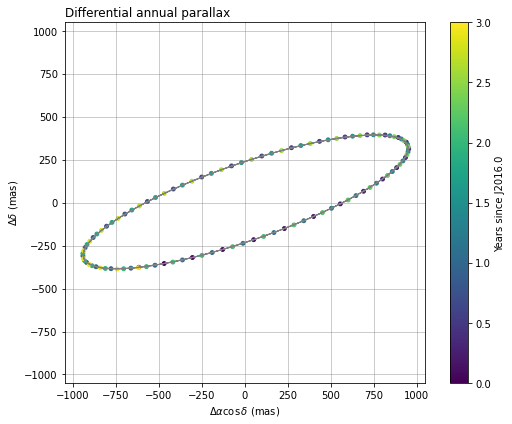

In [9]:
relative_ra = Angle(
  (apparent[:, 0, 0] - apparent[:, 1, 0]) * u.deg,
).wrap_at(180 * u.deg)
relative_x = relative_ra.to_value(u.mas) * np.cos(center.dec.to_value(u.rad))
relative_y = (apparent[:, 0, 1] - apparent[:, 1, 1]) * u.deg.to(u.mas)

limit = (
  1.1
  * np.abs(
    np.column_stack([
      relative_x,
      relative_y,
    ])
  ).max()
)

fig, ax = plt.subplots(figsize=(7.8, 6))
ax.plot(relative_x, relative_y, color='gray', lw=1)
points = ax.scatter(
  relative_x,
  relative_y,
  c=elapsed_year,
  s=15,
  cmap='viridis',
)
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_aspect(1.0, adjustable='box')
ax.grid(True, color='gray', alpha=0.5)
ax.set_title('Differential annual parallax', loc='left')
ax.set_xlabel(r'$\Delta\alpha\cos\delta$ (mas)')
ax.set_ylabel(r'$\Delta\delta$ (mas)')
fig.colorbar(points, ax=ax, label='Years since J2016.0')
fig.tight_layout()
plt.show()

## Summary

- `AstrometricCatalog` stores ICRS position, proper motion, parallax, and reference epoch.
- `GeoCentric(obstime)` describes the observer state used for apparent-coordinate calculation.
- `AstrometricCatalog.propagate(observer)` applies space motion and transforms into the observer frame.
- The result is a one-dimensional `SourceCatalog` suitable for the differentiable astrometric model.
- Telescope optics operate on the resulting apparent sky coordinates and do not propagate catalog epochs.